In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('train.csv') #Load the data
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# Group by survival

In [5]:
#Group by Class

survival_by_class = df.groupby('Pclass')['Survived'].mean()
print('Survival Rate by Class:\n',survival_by_class)

Survival Rate by Class:
 Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [6]:
#Group by gender

survival_by_sex = df.groupby('Sex')['Survived'].mean()
print('\nSurvival Rate by Sex:\n',survival_by_sex)


Survival Rate by Sex:
 Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


In [7]:
#Group by age

survival_by_age = df.groupby(['Pclass','Age'])['Survived'].mean()
print("\nSurvival Rate by Class+Sex:\n",survival_by_age)


Survival Rate by Class+Sex:
 Pclass  Age  
1       0.92     1.0
        2.00     0.0
        4.00     1.0
        11.00    1.0
        14.00    1.0
                ... 
3       61.00    0.0
        63.00    1.0
        65.00    0.0
        70.50    0.0
        74.00    0.0
Name: Survived, Length: 182, dtype: float64


# Clean and Plot

In [8]:
df.Age.fillna(df.Age.mean(), inplace=True)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

C:\Users\haris\AppData\Local\Temp\ipykernel_1912\761251825.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.Age.fillna(df.Age.mean(), inplace=True)


Text(0, 0.5, 'Survaival Rate')

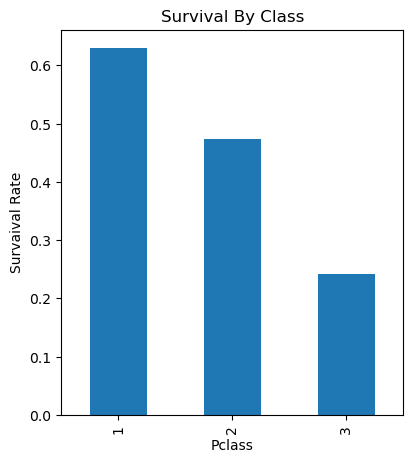

In [35]:
#Plot 1 - Survival by Class

plt.figure(figsize=[15,5])
plt.subplot(1,3,1)
survival_by_class.plot(kind='bar')
plt.title("Survival By Class")
plt.ylabel("Survaival Rate")

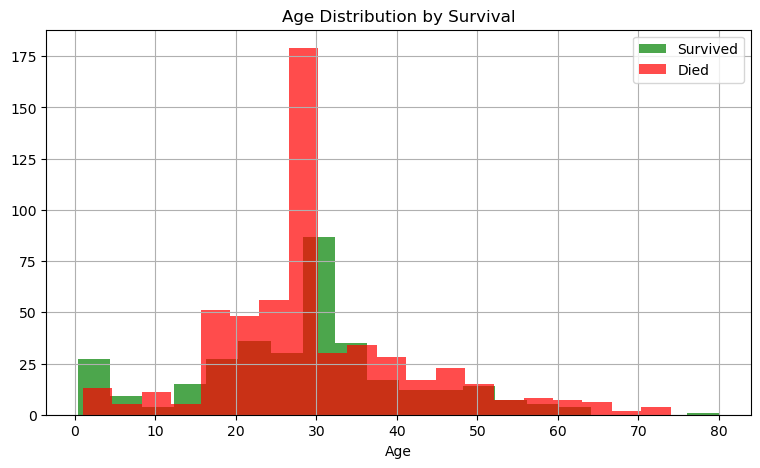

In [56]:
# Plot 2 - Age Distribution by Survival

plt.figure(figsize=[20,5])
plt.subplot(1,2,2)
df[df['Survived']==1]['Age'].hist(bins=20, alpha = 0.7, label = 'Survived', color='green')
df[df['Survived']==0]['Age'].hist(bins=20, alpha = 0.7, label = 'Died', color='red')
plt.legend()
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.show()

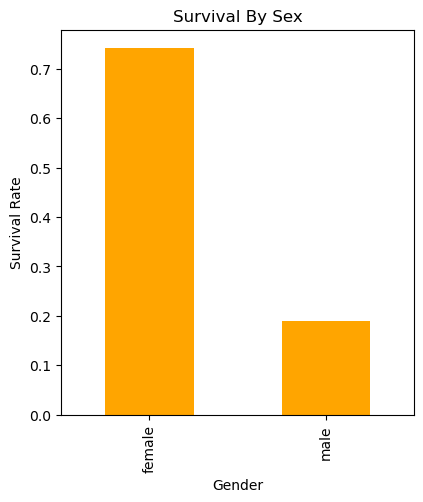

In [78]:
# Plot 3 - Survival by Sex

plt.figure(figsize=[10,5])
plt.subplot(1,2,1)
survival_by_sex.plot(kind='bar', color = 'orange')
plt.title('Survival By Sex')
plt.ylabel('Survival Rate')
plt.xlabel('Gender')
plt.show()

# Insights

In [89]:
print("Key insights")
print("Women Survival Rate is 74% while Men Survival Rate is 18%")
print("- 1st Class: 63% survival vs 3rd Class: 25%")
print("- FamilySize impact:", df.groupby('FamilySize')['Survived'].mean())

Key insights
Women Survival Rate is 74% while Men Survival Rate is 18%
- 1st Class: 63% survival vs 3rd Class: 25%
- FamilySize impact: FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64
